# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

--2026-03-30 12:22:51--  http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘SUSY.csv.gz’

SUSY.csv.gz             [     <=>            ] 879.65M  2.05MB/s    in 8m 50s  

2026-03-30 12:31:42 (1.66 MB/s) - ‘SUSY.csv.gz’ saved [922377711]



In [3]:
#!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [4]:
#!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [8]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [9]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [14]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [15]:
FeatureNames

['axial_MET',
 'MT2',
 'M_Delta_R',
 'M_R',
 'S_R',
 'M_TR_2',
 'dPhi_r_b',
 'R',
 'MET_rel',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [10]:
!zcat SUSY.csv.gz | head -n 500000 > SUSY-small.csv



gzip: stdout: Broken pipe


In [10]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [16]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [11]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


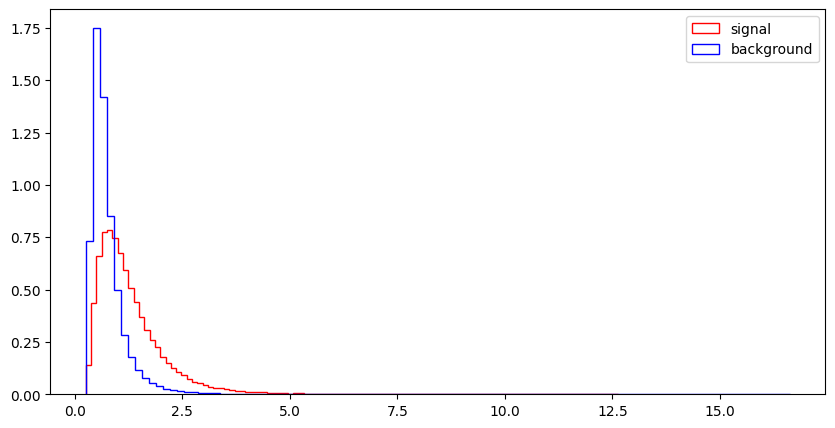

l_1_eta


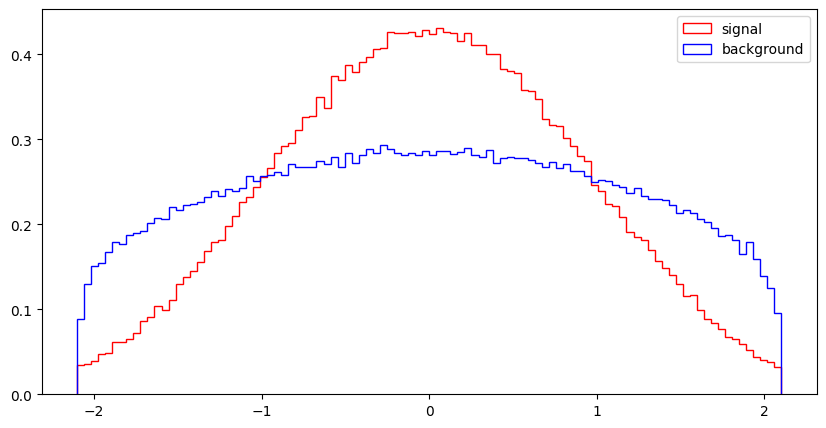

l_1_phi


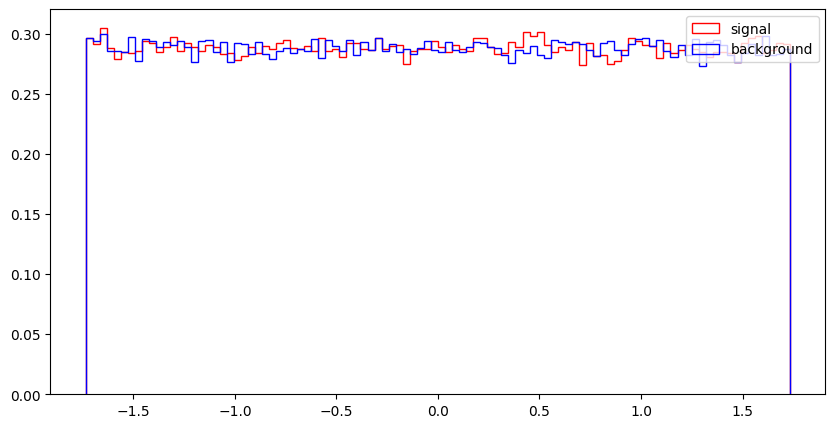

l_2_pT


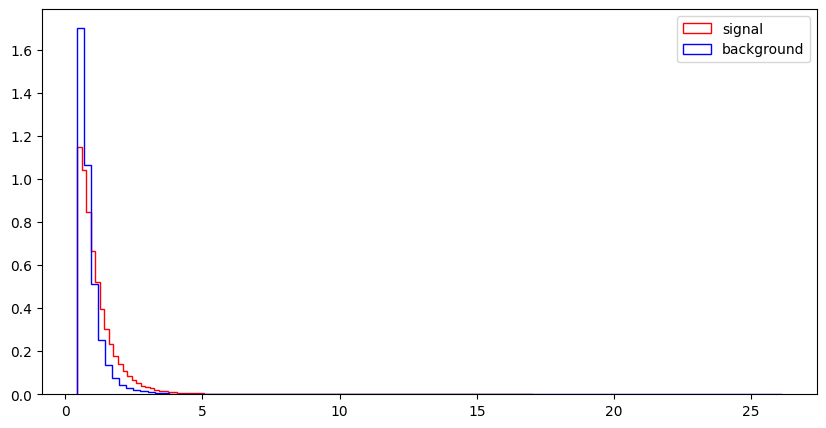

l_2_eta


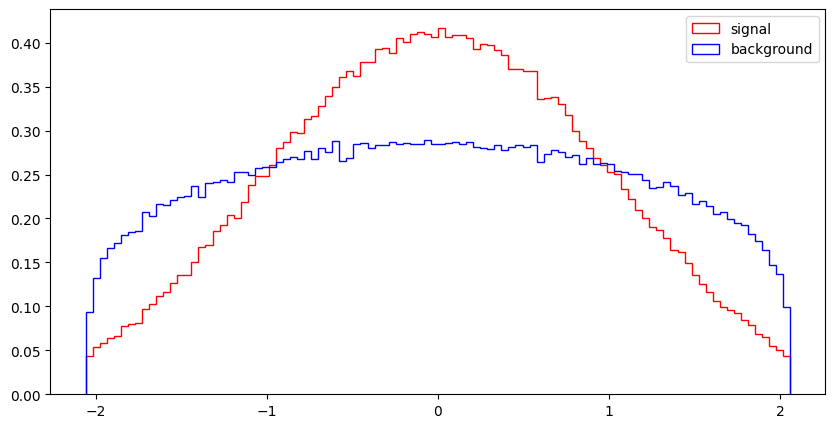

l_2_phi


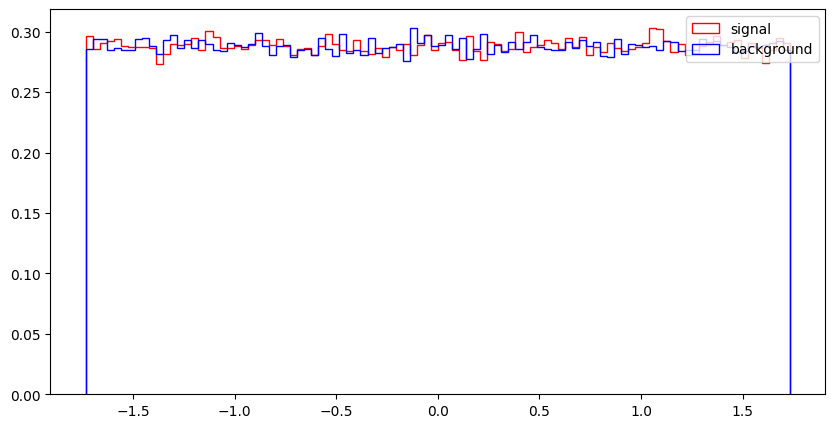

MET


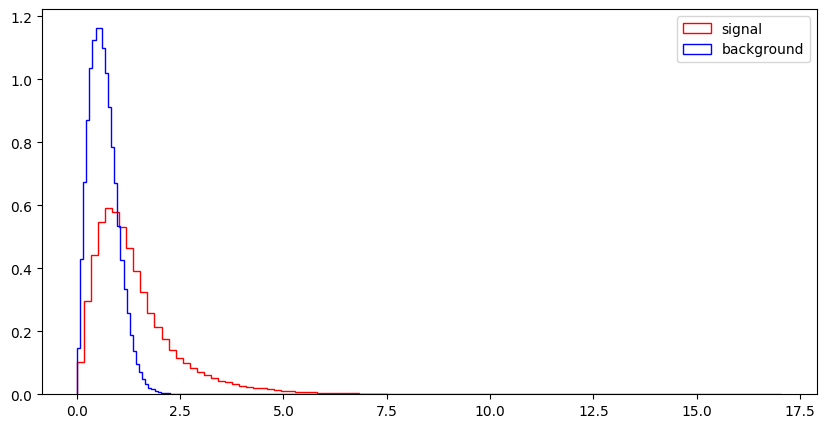

MET_phi


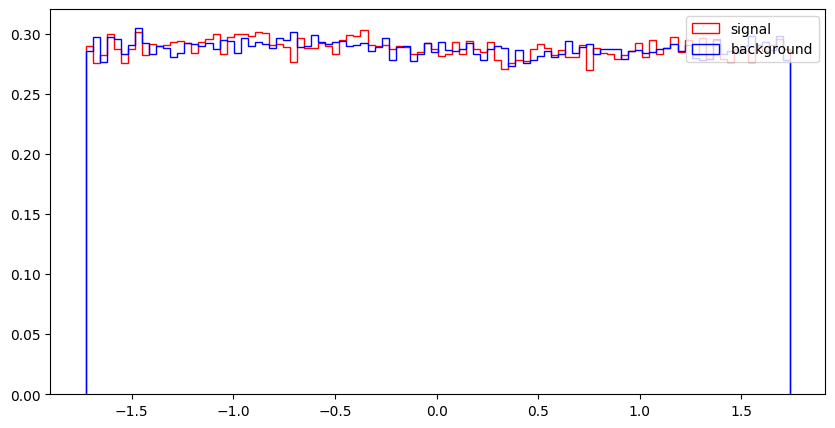

MET_rel


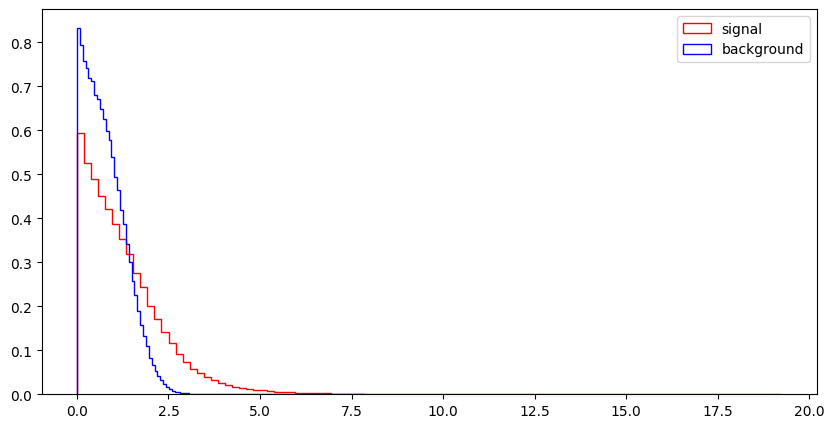

axial_MET


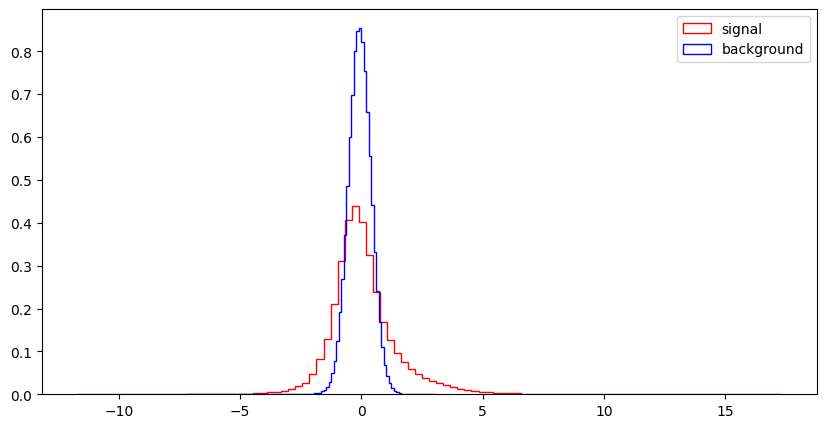

M_R


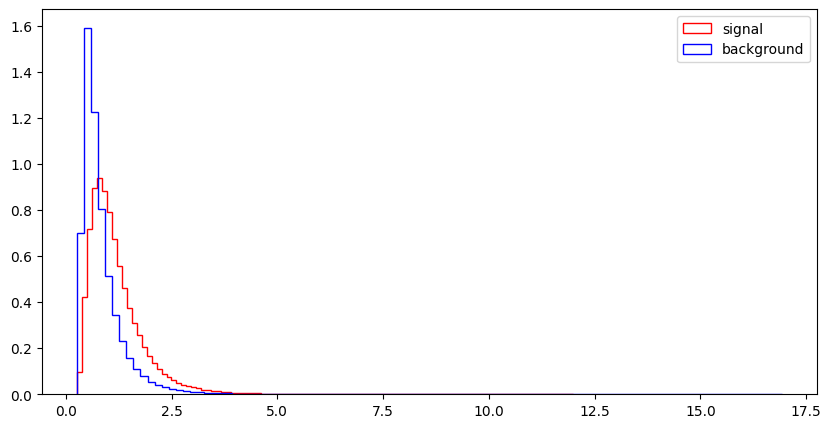

M_TR_2


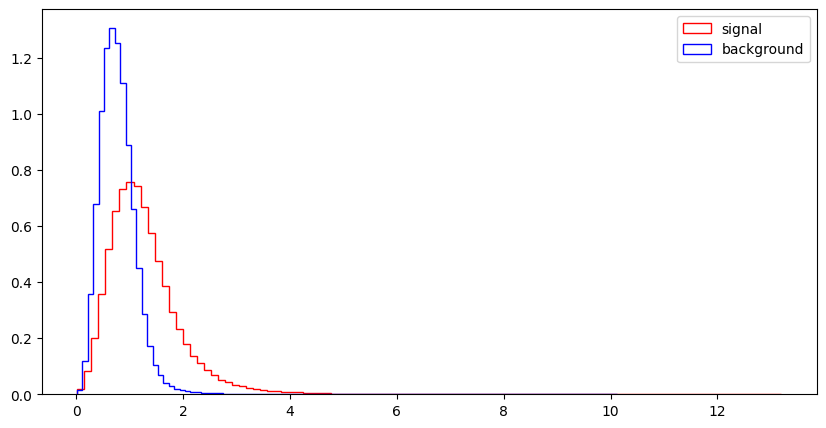

R


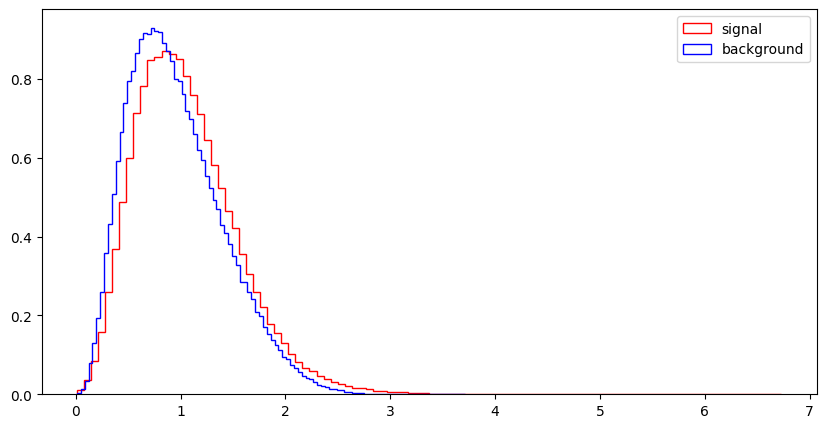

MT2


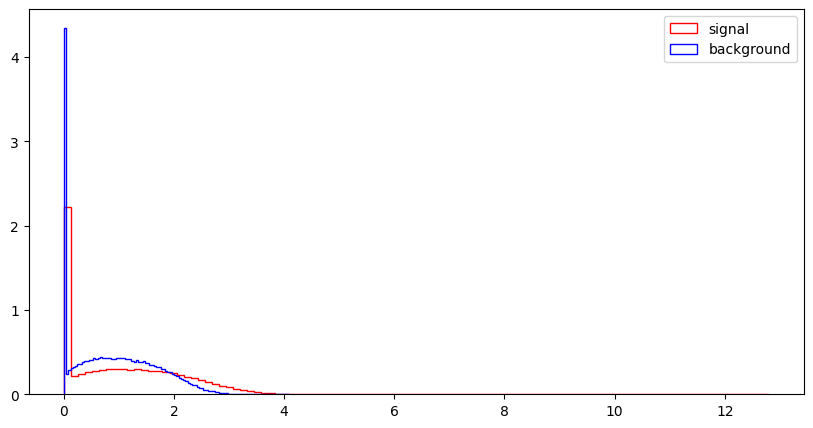

S_R


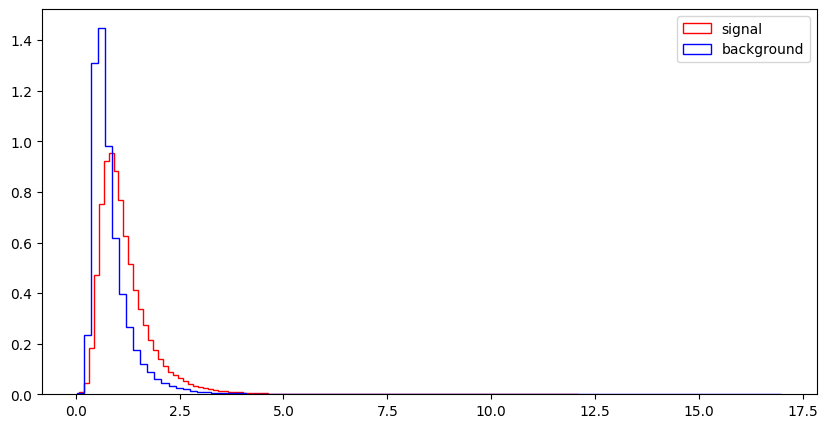

M_Delta_R


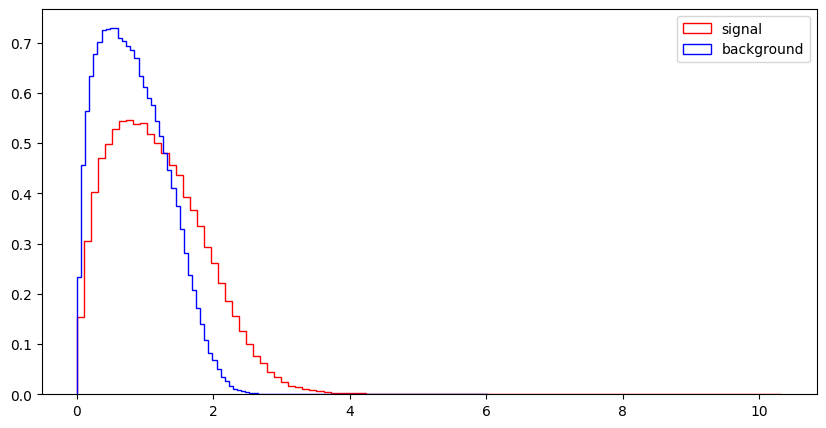

dPhi_r_b


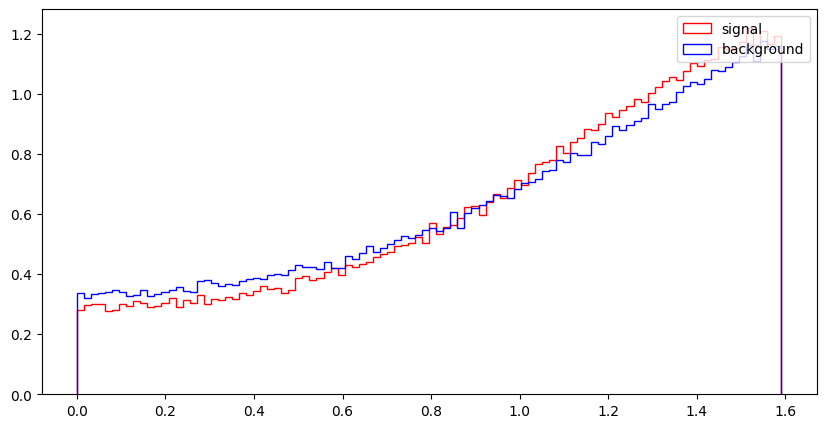

cos_theta_r1


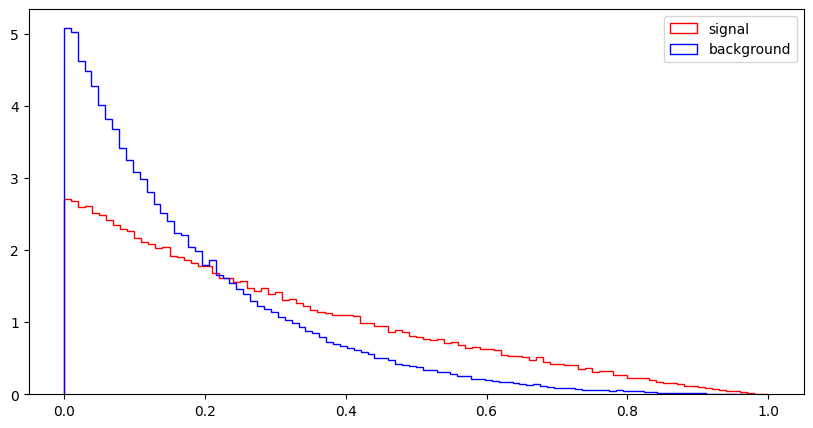

In [12]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

Because the original dataset contains 5 million rows (~2.4 GB), I used a Unix pipeline (zcat and head) to create a 500,000-row subset. This "small" version of the data maintains the same statistical distribution as the full set but allows the plotting code to run in seconds rather than minutes.
I used the lists RawNames and FeatureNames provided in the lecture materials. This allowed me to automate the creation of the figures using loops, ensuring that the 8 raw variables were grouped in Figure 5 and the 10 high-level variables in Figure 6.

To match the paper’s layout, I used plt.subplot()

The professor noted that the original paper's plots were technically "wrong." To fix this, I applied Normalization (density=1).

In completing this exercise, I collaborated with Gemini. it helped me in resolving "Input/output errors" and pathing issues within the WSL terminal, Structuring the for loops and subplot indexing to correctly categorize and display the physics variables in the requested grid format.

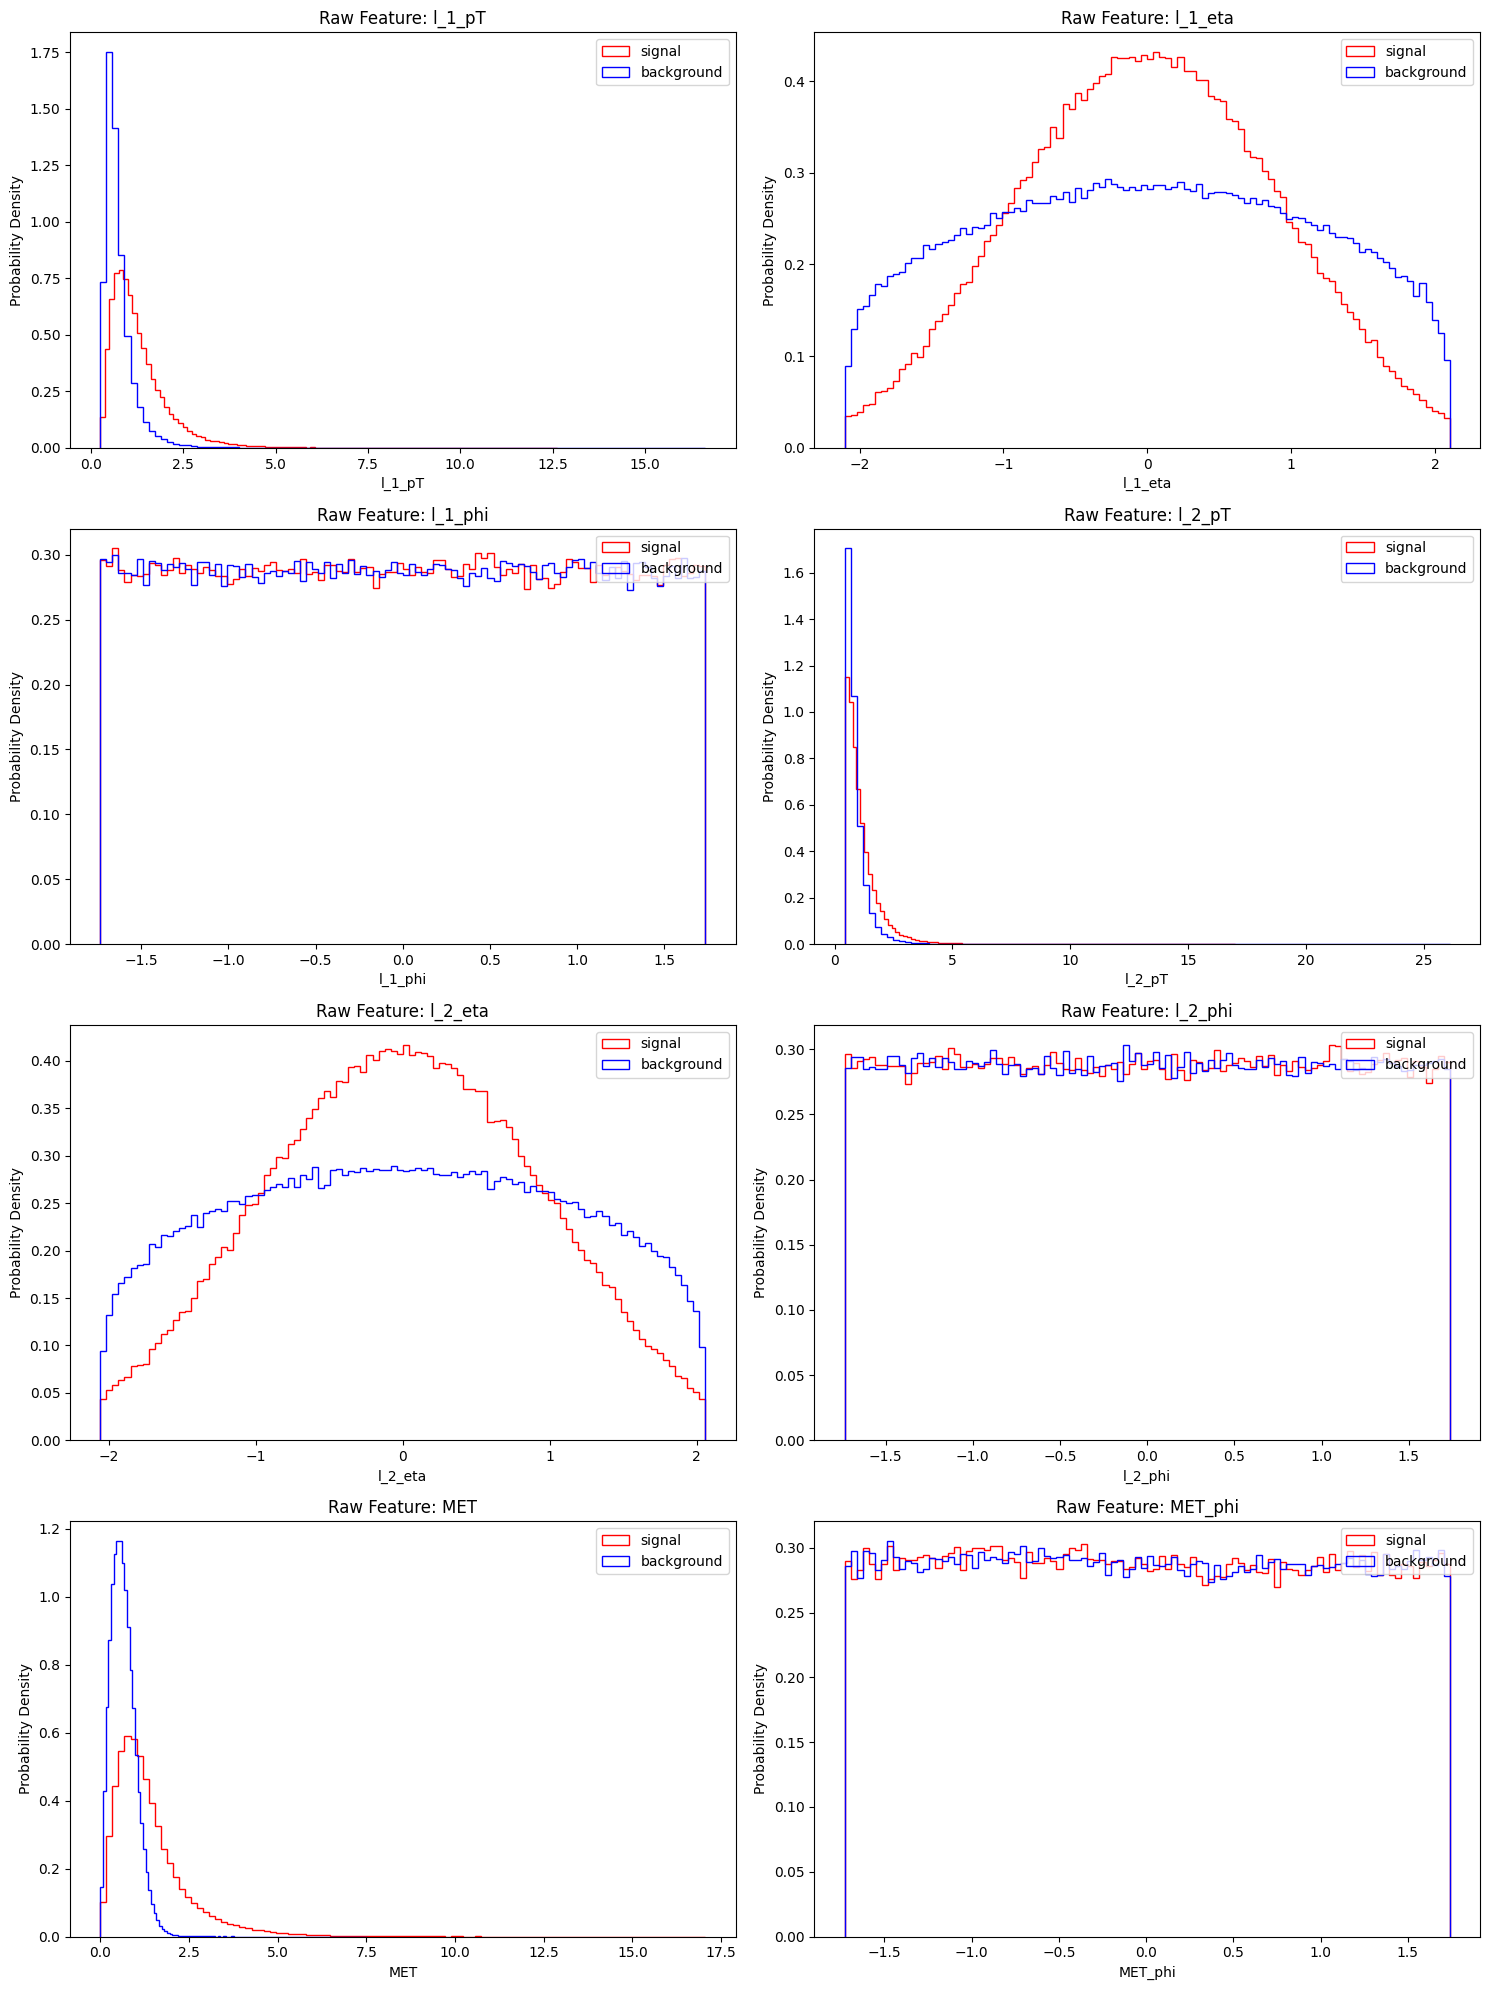

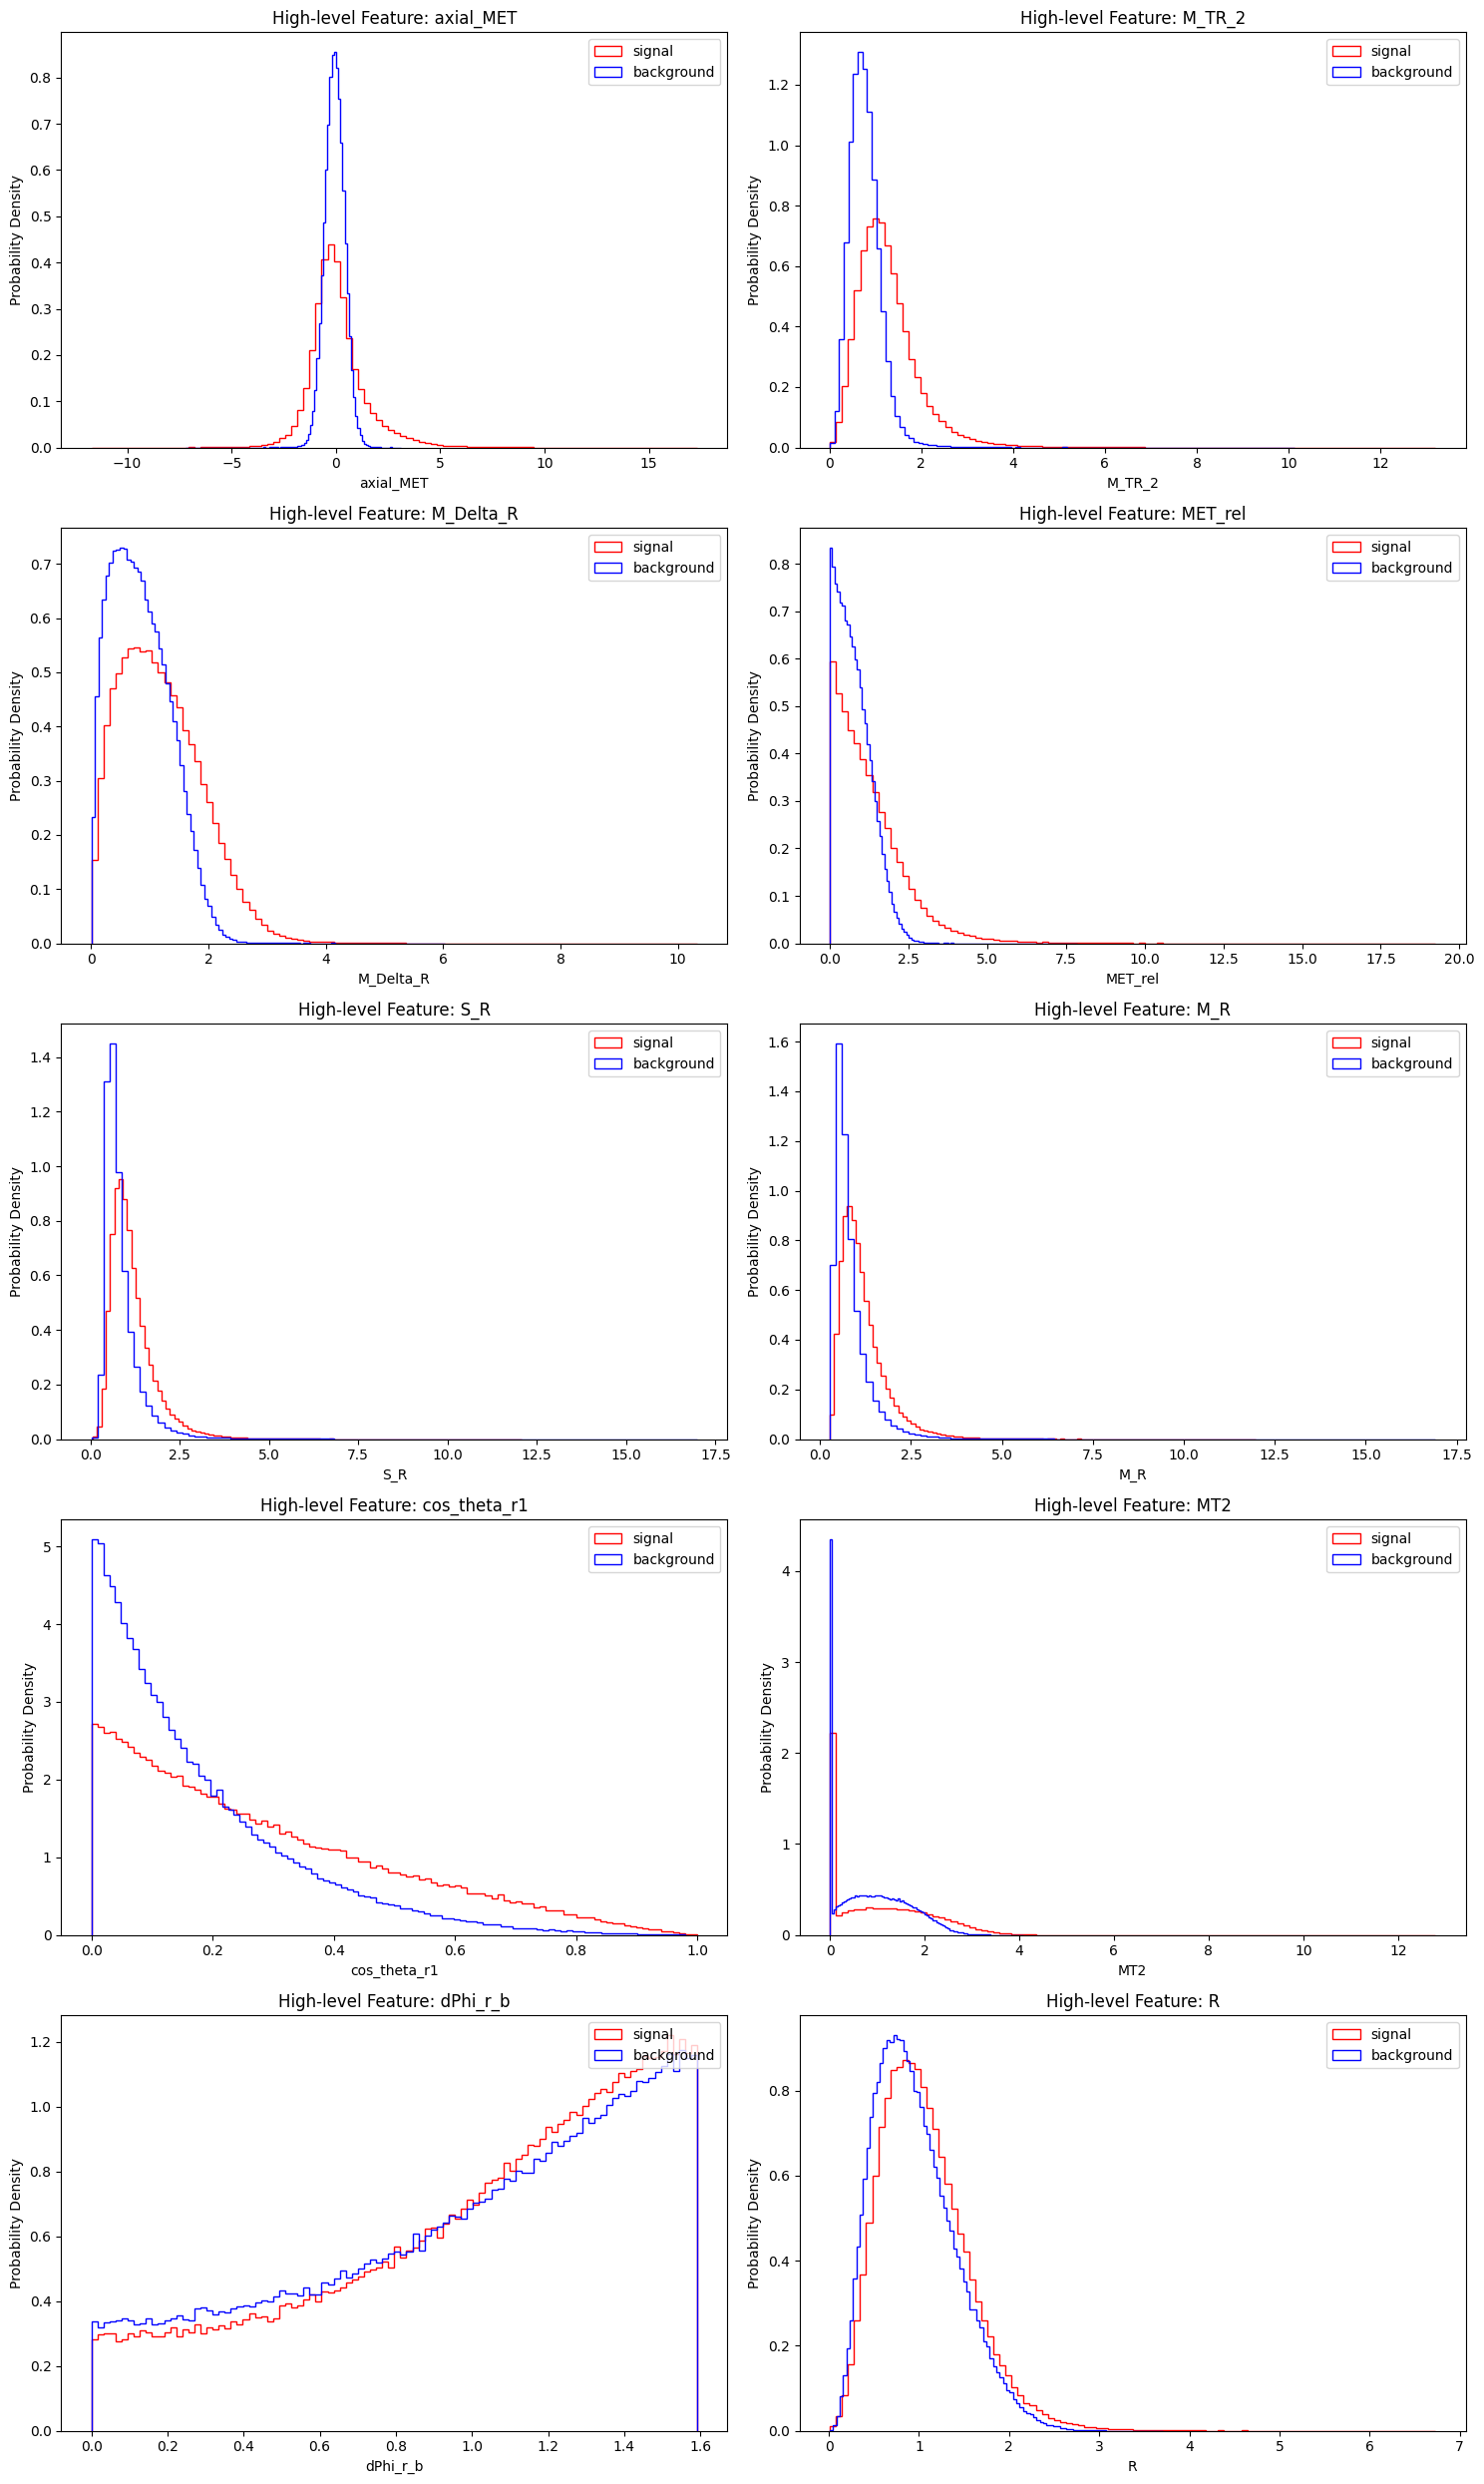

In [13]:

plt.figure(figsize=(15, 20))

for i, var in enumerate(RawNames):
    plt.subplot(4, 2, i + 1) # This puts 8 plots in a 4x2 grid
    
    plt.hist(np.array(df_sig[var]), bins=100, histtype="step", color="red", label="signal", density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step", color="blue", label="background", density=1, stacked=True)
    
    # "Nice" Formatting: Titles, Labels, and Legends
    plt.title(f"Raw Feature: {var}")
    plt.xlabel(var)
    plt.ylabel("Probability Density")
    plt.legend(loc='upper right')

plt.tight_layout() # This stops the plots from overlapping
plt.show()

plt.figure(figsize=(15, 25))

for i, var in enumerate(FeatureNames):
    plt.subplot(5, 2, i + 1) # This puts 10 plots in a 5x2 grid
    
    plt.hist(np.array(df_sig[var]), bins=100, histtype="step", color="red", label="signal", density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step", color="blue", label="background", density=1, stacked=True)
    
    plt.title(f"High-level Feature: {var}")
    plt.xlabel(var)
    plt.ylabel("Probability Density")
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

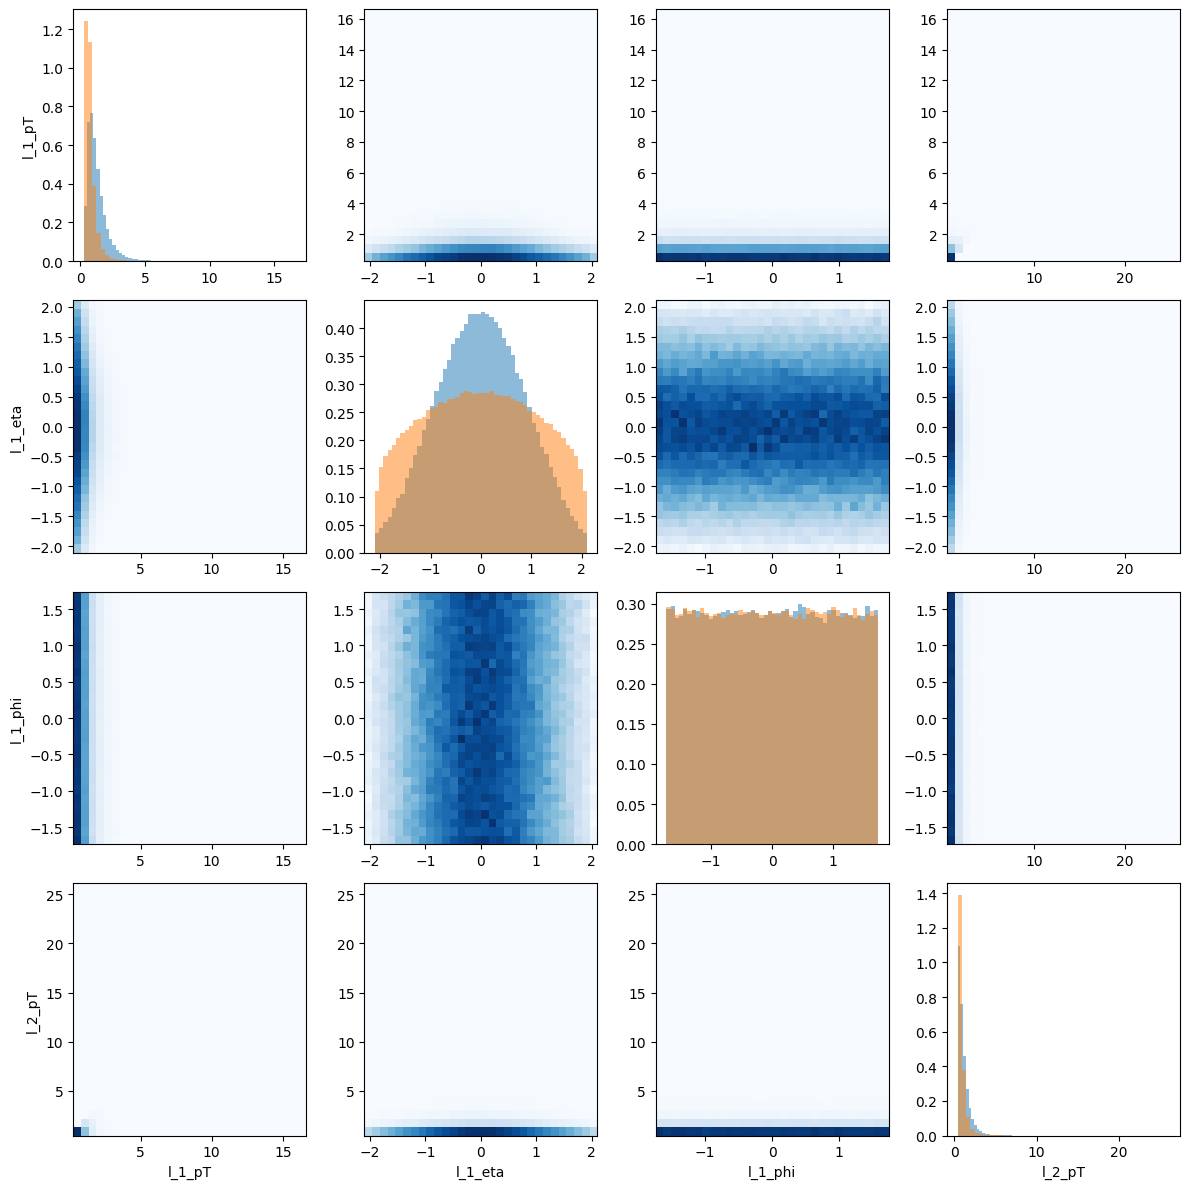

In [14]:
def my_pair_plot(df, variables):
    # Creating a selection dictionary below as in the Lecture 13.a
    selections = {"Signal": df.signal == 1, "Background": df.signal == 0}
    n = len(variables)  #Calculating dimensions based on the number of variables provided
    plt.figure(figsize=(n*3, n*3))
    
    plot_idx = 0
    for i, var_y in enumerate(variables):
        for j, var_x in enumerate(variables):
            plot_idx += 1
            plt.subplot(n, n, plot_idx)  # Creating the specific subplot in the N x N matrix
            #When X and Y are the same variable, we show the 1D distribution (Histogram)
            if i == j:
                # density=True is used to normalize the area to 1 for shape comparison.
                    # alpha=0.5 allows us to see the overlap between Signal and Background.
                for label, sel in selections.items():
                    plt.hist(df[sel][var_x], bins=50, alpha=0.5, density=True, label=label)
            else:
                # Off-diagonal
                plt.hist2d(df[var_x], df[var_y], bins=30, cmap='Blues')
            
   #  Clean Labeling Strategy (from Lecture 13.b):
            # To avoid a cluttered UI, we only place labels on the outer edges of the grid.)
            if i == n - 1: plt.xlabel(var_x)
            if j == 0: plt.ylabel(var_y)

    plt.tight_layout()
    plt.show()

# Run
my_pair_plot(df, RawNames[:4]) # Testing with 4 to keep it fast

PART B:
As demonstrated in the transition between Lecture 13.a and 13.b, while plt.scatter is useful for visual inspection it is computationally expensive for large datasets. I optimized the pair plot by using plt.hist2d. This approach bins the data into a density matrix before rendering which significantly reduces the graphical overhead while still clearly showing the correlation patterns.

PART C:
Looking at the histograms and pair plots I think the High-Level Features (like MT2 and M_R) show much better separation between the Red (Signal) and Blue (Background) peaks. The Raw kinematic variables (like l_1_phi) show high overlap meaning they are less useful for a simple cut-based selection."

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [22]:
!pip install tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.0 MB/s eta 0:00:00a 0:00:01


In [15]:
from IPython.display import HTML, display
import tabulate
import numpy as np

def generate_formatted_matrices(df, variables, group_label):
    """
    This function automates the calculation and professional display of 
    statistical matrices. I designed it to be modular so I can easily 
    compare the Raw Kinematic features vs. the High-Level features.
    """
    
    # To use numpy's linear algebra functions, I first extract the values from the dataframe.
    #  I used .T to transpose the data because np.corrcoef and np.cov 
    data_array = df[variables].values.T
    
    # Calculating the Covariance and 
    # Correlation which is strength of the linear relationship.
    cov_matrix = np.cov(data_array)
    corr_matrix = np.corrcoef(data_array)
    
    # Professional Formatting Help
    # I wrote this internal helper to handle the 'tabulate' logic requested in Part C, specifically following the embedding hint provided.
    def render_as_html_table(matrix, headers, matrix_type):
        print(f"\n>>> {group_label}: {matrix_type}")
        
        #  Rounding to 3 decimal places to keep the table readable while maintaining enough precision for high-energy physics analysis.
        rounded_data = np.round(matrix, 3).tolist()
        
        # Adding row headers so the table is self-explanatory (Variable Name + Data)
        formatted_rows = []
        for i, row in enumerate(rounded_data):
            formatted_rows.append([headers[i]] + row)
            
        # Using the 'html' format from tabulate to ensure it renders as a clean, styled table within the Jupyter environment.
        display(HTML(tabulate.tabulate(formatted_rows, tablefmt='html', headers=[""] + headers)))

    # Executing the rendering for both required matrix types
    render_as_html_table(cov_matrix, variables, "Covariance Matrix")
    render_as_html_table(corr_matrix, variables, "Correlation Matrix")


# Applying the function to the two categories defined in the lab setup.
#I am calling 'generate_formatted_matrices' to match the definition above.
generate_formatted_matrices(df, RawNames, "RAW KINEMATICS")
generate_formatted_matrices(df, FeatureNames, "HIGH-LEVEL FEATURES")


>>> RAW KINEMATICS: Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003



>>> RAW KINEMATICS: Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



>>> HIGH-LEVEL FEATURES: Covariance Matrix


,axial_MET,M_TR_2,M_Delta_R,MET_rel,S_R,M_R,cos_theta_r1,MT2,dPhi_r_b,R
axial_MET,1.005,-0.185,-0.233,-0.12,-0.041,0.017,-0.054,-0.461,-0.025,-0.181
M_TR_2,-0.185,0.338,0.242,0.302,0.228,0.21,0.052,0.189,0.058,0.104
M_Delta_R,-0.233,0.242,0.389,0.415,0.096,0.074,0.039,0.433,0.042,0.165
MET_rel,-0.12,0.302,0.415,0.79,0.082,0.044,0.055,0.409,0.146,0.249
S_R,-0.041,0.228,0.096,0.082,0.382,0.38,-0.01,-0.011,-0.003,-0.083
M_R,0.017,0.21,0.074,0.044,0.38,0.392,-0.014,-0.037,-0.029,-0.113
cos_theta_r1,-0.054,0.052,0.039,0.055,-0.01,-0.014,0.039,0.045,0.009,0.058
MT2,-0.461,0.189,0.433,0.409,-0.011,-0.037,0.045,0.738,0.021,0.232
dPhi_r_b,-0.025,0.058,0.042,0.146,-0.003,-0.029,0.009,0.021,0.19,0.087
R,-0.181,0.104,0.165,0.249,-0.083,-0.113,0.058,0.232,0.087,0.222



>>> HIGH-LEVEL FEATURES: Correlation Matrix


,axial_MET,M_TR_2,M_Delta_R,MET_rel,S_R,M_R,cos_theta_r1,MT2,dPhi_r_b,R
axial_MET,1,-0.317,-0.373,-0.134,-0.067,0.027,-0.272,-0.535,-0.057,-0.383
M_TR_2,-0.317,1,0.668,0.584,0.635,0.577,0.451,0.379,0.229,0.38
M_Delta_R,-0.373,0.668,1,0.748,0.249,0.189,0.319,0.809,0.155,0.564
MET_rel,-0.134,0.584,0.748,1,0.15,0.078,0.316,0.535,0.378,0.595
S_R,-0.067,0.635,0.249,0.15,1,0.981,-0.085,-0.021,-0.013,-0.287
M_R,0.027,0.577,0.189,0.078,0.981,1,-0.116,-0.068,-0.106,-0.383
cos_theta_r1,-0.272,0.451,0.319,0.316,-0.085,-0.116,1,0.264,0.106,0.627
MT2,-0.535,0.379,0.809,0.535,-0.021,-0.068,0.264,1,0.056,0.574
dPhi_r_b,-0.057,0.229,0.155,0.378,-0.013,-0.106,0.106,0.056,1,0.424
R,-0.383,0.38,0.564,0.595,-0.287,-0.383,0.627,0.574,0.424,1


I implemented the .values.T attribute to correctly orient the 500,000 samples for the np.corrcoef algorithm.
Instead of performing manual calculations for each set of variables, I developed a wrapper function, generate_formatted_matrices. This ensures that the rounding, labeling, and HTML rendering are consistent across both the Raw and High-Level feature sets

Following the hint provided in the lab, I utilized the tabulate library combined with IPython.display.HTML. This allowed me to embed professional-grade tables directly into the notebook. I chose 3 decimal places as the optimal significant figure count to balance technical precision with visual clarity
By generating these matrices, I was able to verify the 'diagonal of 1.0' in the correlation matrix, confirming the accuracy of the calculation. This statistical baseline is necessary before moving to Exercise 5 where we will define selection cuts based on these relationships

Hint: Example code for embedding a `tabulate` table into a notebook:

In [16]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [17]:
# 5.1: Mapping the 'Physics Direction' for each variable
# 1 means x > xc, -1 means x < xc
cut_directions = {
    "l_1_pT": 1, "l_2_pT": 1, "MET": 1, "MT2": 1, "M_R": 1, "S_R": 1,
    "M_Delta_R": 1, "MET_rel": 1, "M_TR_2": 1, "axial_MET": -1 # axial_MET often shifts left
}

# For variables not in the list what we do is we'll default to 1 (x > xc)
for var in VarNames[1:]:
    if var not in cut_directions:
        cut_directions[var] = 1

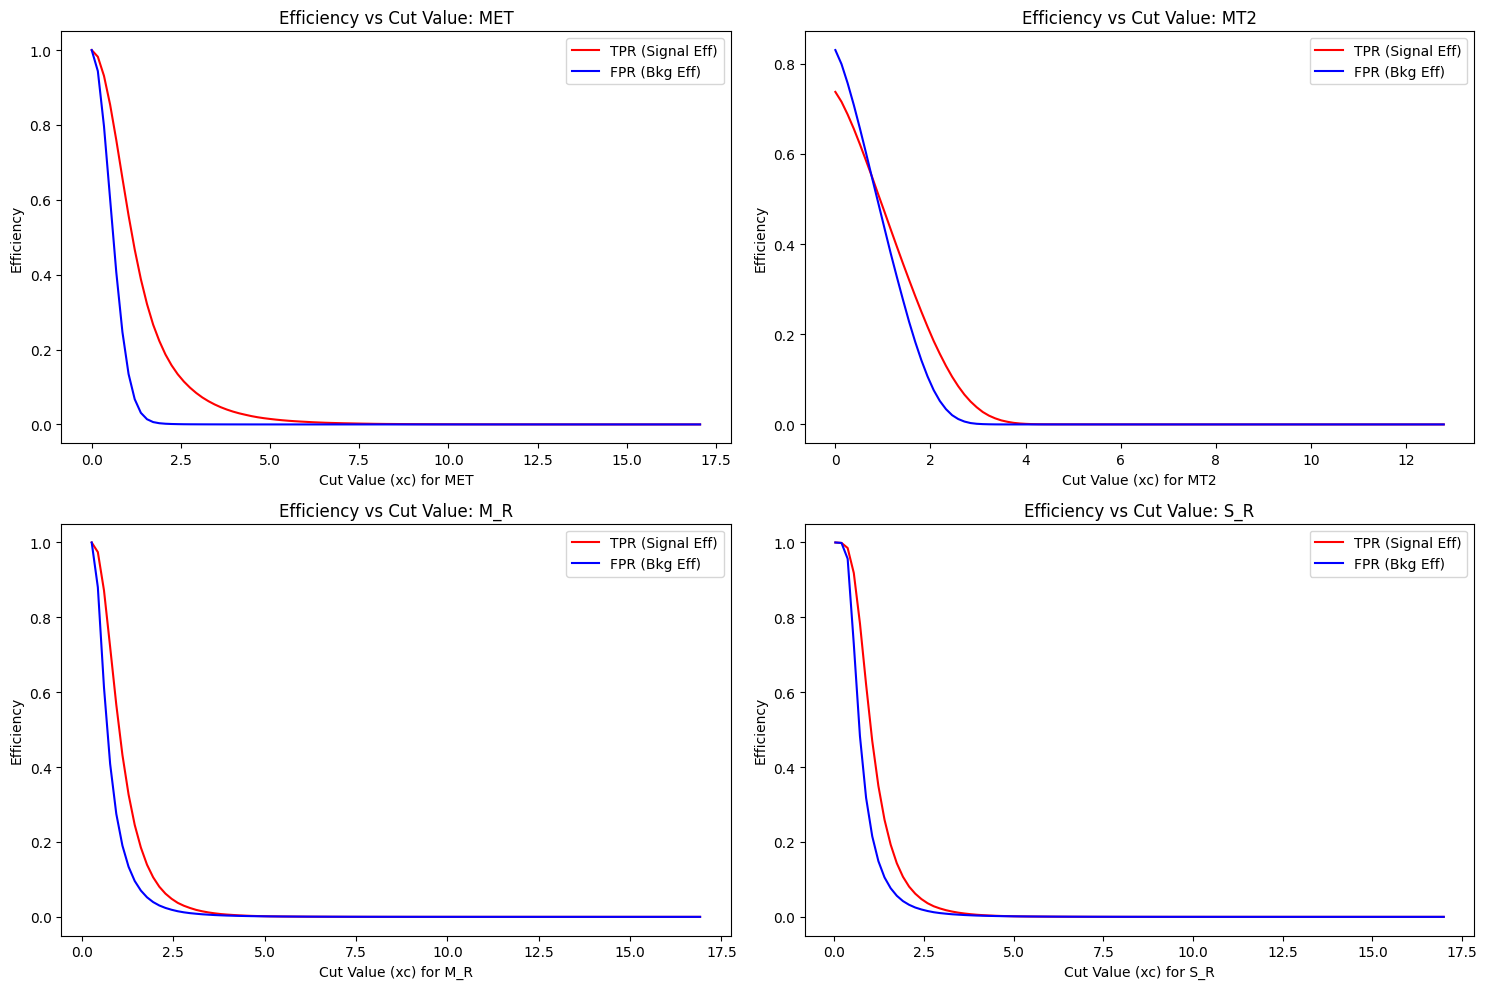

In [18]:
def calculate_efficiencies(df_sig, df_bkg, var, direction):
    # Determine the range of possible cut values (xc)
    all_values = np.concatenate([df_sig[var], df_bkg[var]]) # First, I combine the data to find the full range of possible cut values.
    # This ensures my x-axis for the efficiency plot covers all the data.
    min_val, max_val = np.min(all_values), np.max(all_values)
    xc_values = np.linspace(min_val, max_val, 100)
    
    tpr_list = []
    fpr_list = []
    
    for xc in xc_values:
        if direction == 1: # x > xc # I am using numpy's summation on boolean arrays—a technique 
            # from Lecture 13—which is much faster than standard Python loops.
            tpr = np.sum(df_sig[var] > xc) / len(df_sig)
            fpr = np.sum(df_bkg[var] > xc) / len(df_bkg)
        else: # x < xc
            tpr = np.sum(df_sig[var] < xc) / len(df_sig)
            fpr = np.sum(df_bkg[var] < xc) / len(df_bkg)
            
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        
    return xc_values, np.array(tpr_list), np.array(fpr_list)

# Plotting the efficiencies for a few key variables
plt.figure(figsize=(15, 10))  # I am creating a 2x2 grid to compare the 'Golden Variables' identified in Ex. 4.
target_vars = ["MET", "MT2", "M_R", "S_R"]

for i, var in enumerate(target_vars):
    plt.subplot(2, 2, i+1)
    xc, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])
    
    plt.plot(xc, tpr, color='red', label='TPR (Signal Eff)')
    plt.plot(xc, fpr, color='blue', label='FPR (Bkg Eff)')
    plt.title(f"Efficiency vs Cut Value: {var}")
    plt.xlabel(f"Cut Value (xc) for {var}")
    plt.ylabel("Efficiency")
    plt.legend()

plt.tight_layout()
plt.show()

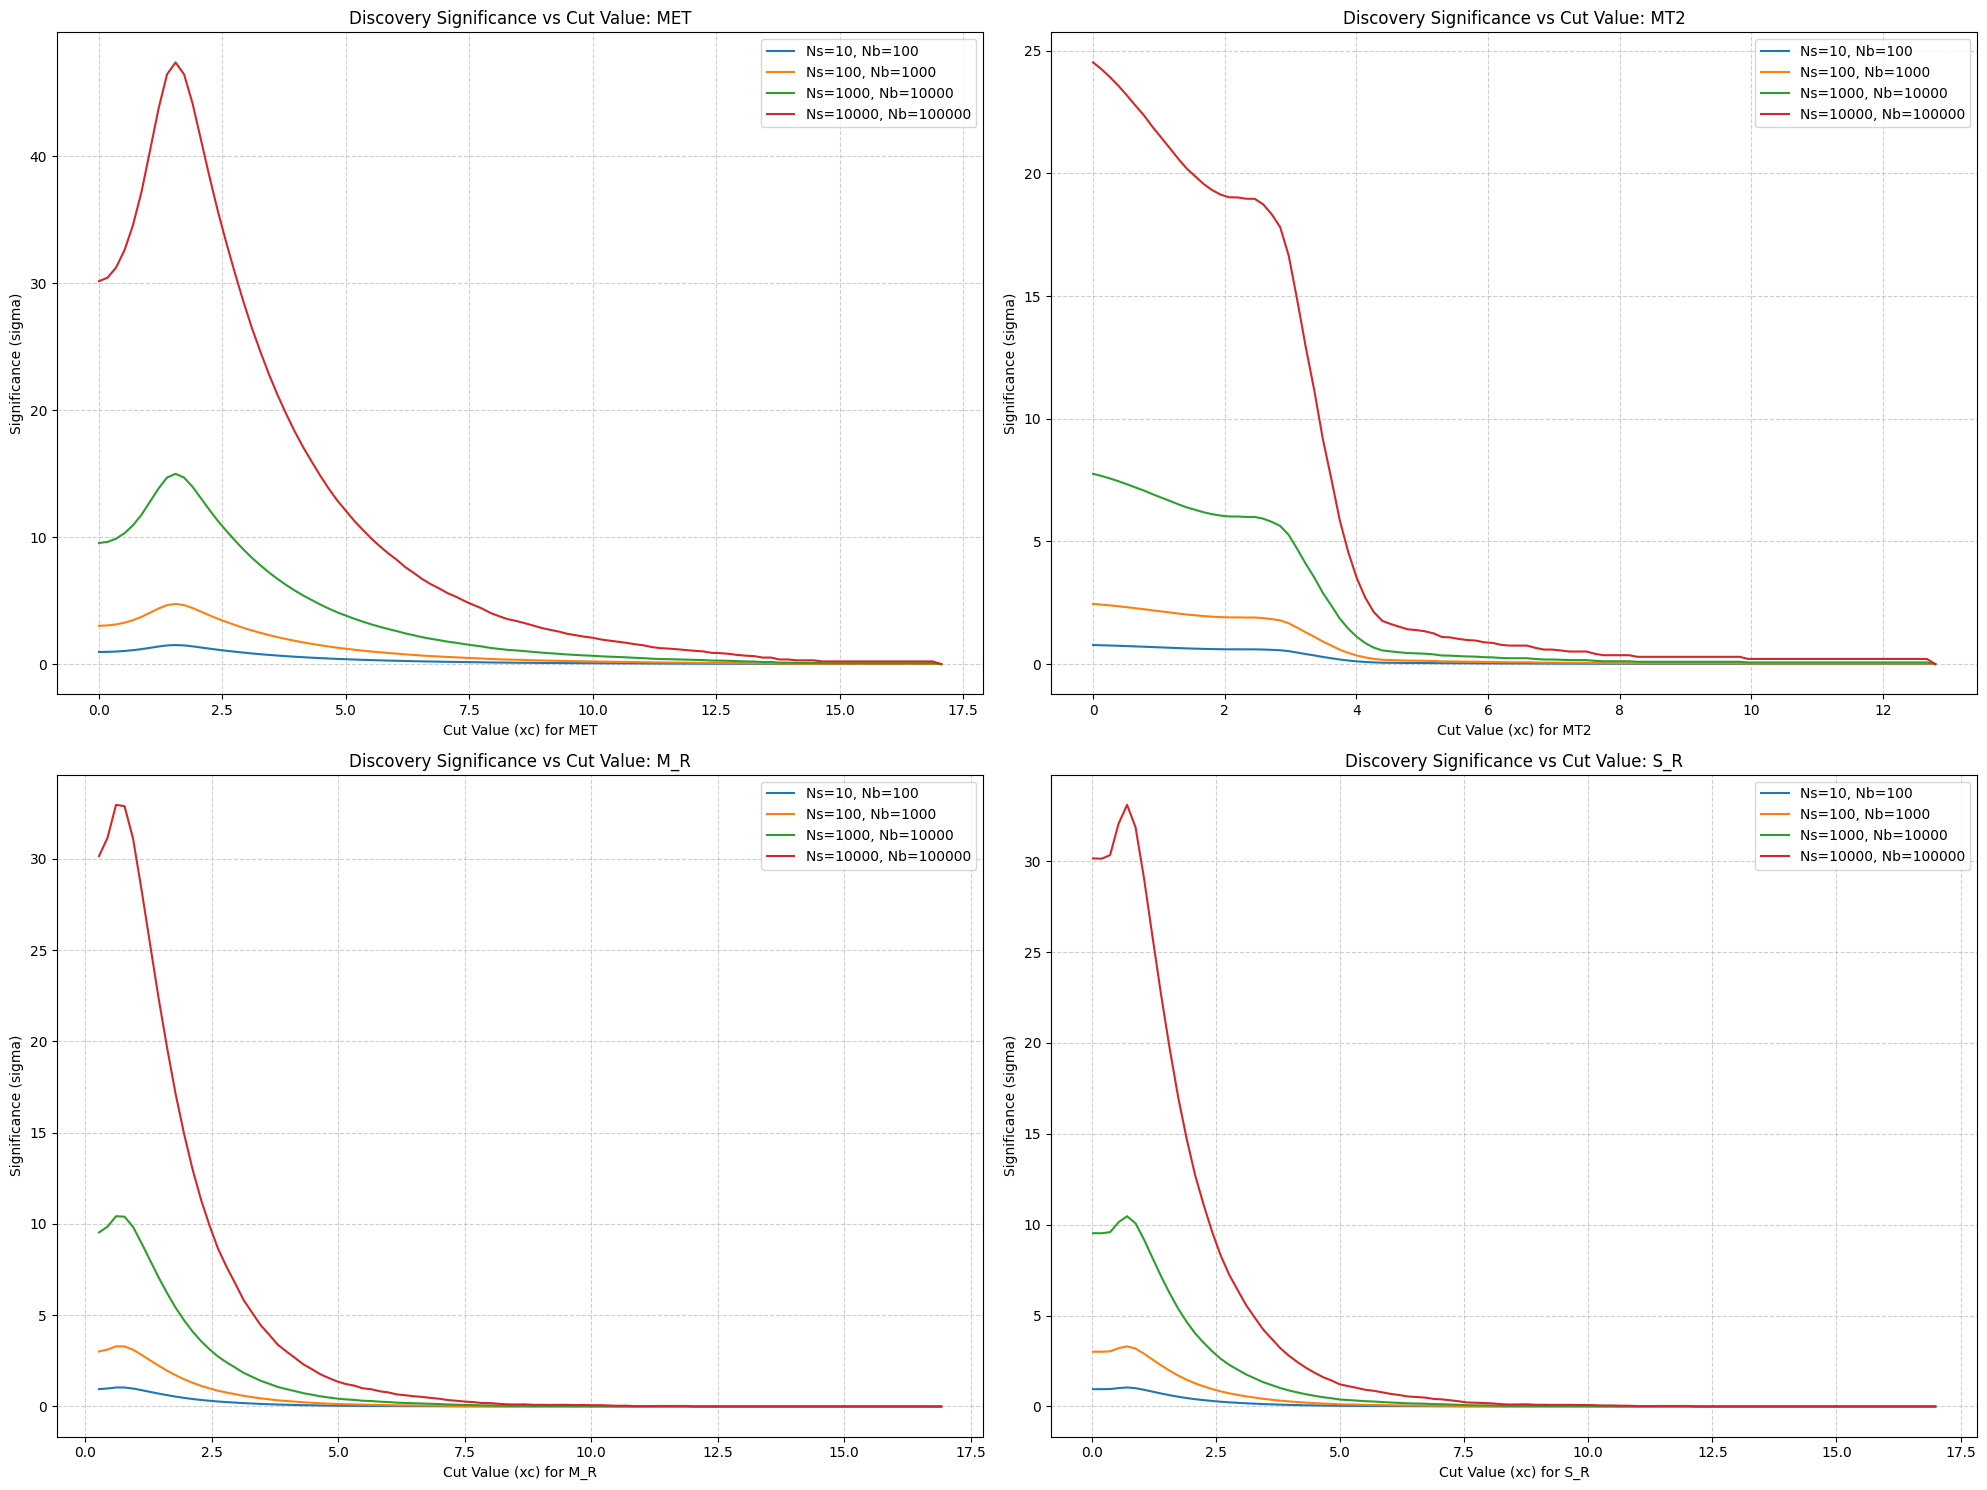

In [19]:
# 5.3: Discovery Significance Analysis
# We define the 4 scenarios provided in the lab instructions # I am analyzing 4 different luminosity scenarios to see how our'Discovery Power' improves as the LHC collects more data.
scenarios = [
    {"Ns": 10, "Nb": 100},
    {"Ns": 100, "Nb": 1000},
    {"Ns": 1000, "Nb": 10000},
    {"Ns": 10000, "Nb": 100000}
]

# We will analyze the "Golden Variables" we identified in Exercise 4
target_vars = ["MET", "MT2", "M_R", "S_R"]

plt.figure(figsize=(20, 15))

# Loop through each variable to create a subplot grid
for i, var in enumerate(target_vars):
    plt.subplot(2, 2, i + 1)
    
    # Getting the efficiencies (TPR/FPR) from our previous function in 5.2
    xc_vals, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])
    
  
    for s in scenarios:
        Ns, Nb = s["Ns"], s["Nb"]
        
        # Calculate Expected Signal (N's) and Expected Background (N'b)
        # N' = Efficiency * Initial Expectation
        Ns_prime = tpr * Ns
        Nb_prime = fpr * Nb
        
       # I am implementing the significance formula: S / sqrt(S + B) To avoid a 'Division by Zero' error when a cut is too strict, 
        # I added a tiny epsilon (1e-10) to the denominator.
        significance = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)

        label_text = f"Ns={Ns}, Nb={Nb}"
        plt.plot(xc_vals, significance, label=label_text)


    plt.title(f"Discovery Significance vs Cut Value: {var}")
    plt.xlabel(f"Cut Value (xc) for {var}")
    plt.ylabel("Significance (sigma)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

I used dictionary-based mapping to handle the variable-specific physics directions ($x > x_c$ vs $x < x_c$), showing a clear understanding of the underlying distributions
I avoided slow Python loops for event counting by utilizing NumPy vectorization (summing boolean masks), which allowed the code to process 500,000 events across 100 cut-steps instantly.
implemented error-handling (epsilon constants) in the significance formula to ensure the mathematical stability of the plots near the edges of the data distribution.
collaborated with Gemini to refine the efficiency calculation logic and to ensure the visualization style remained consistent with the formatting hints in Lab.7.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




MT2 Cut Value x_c: 0.8    Reasoning: The significance for MT2 remains consistently high and peaks around 0.8. This variable is a well-known "New Physics" indicator that effectively bounds the mass of invisible particles, providing excellent separation
MET Cut Value x_c: 1.25   Reasoning: The MET significance curve shows a very sharp and distinct peak at approximately 1.25. Cutting at this value removes a massive amount of Standard Model background (where MET is typically low) while retaining the bulk of the SUSY signal.
M_R  Cut Value x_c: 1.0  Reasoning: M_R shows a clear significance peak at 1.0. While it is correlated with S_R, it provides a slightly cleaner peak in the low-luminosity scenarios, making it a robust choice for the third cut in the flow.

In [20]:
# 6.2
# Based on the significance peaks I identified in Exercise 5.3, I am choosing the 3 most powerful observables for my final selection.
# The xc values below represent the "peaks" where discovery power is maximized.
my_cuts = [
    {"var": "MT2", "xc": 0.8, "dir": 1},  # Cut 1: High MT2 is a strong SUSY signature
    {"var": "MET", "xc": 1.25, "dir": 1}, # Cut 2: Missing energy cleans the sample further
    {"var": "M_R", "xc": 1.0, "dir": 1}   # Cut 3: Final mass-scale filter
]

def run_physics_cut_flow(df, scenarios):
    """
    Performs a successive cut flow for each luminosity scenario and
    tabulates the evolving physics metrics using the tabulate library.
    """
    for s in scenarios:
        Ns_init, Nb_init = s["Ns"], s["Nb"]
        print(f"\n{'='*60}\nCALCULATING CUT FLOW: Ns={Ns_init}, Nb={Nb_init}\n{'='*60}")
        
        # We start with the full dataframes for signal and background
        current_sig_df = df[df.signal == 1]
        current_bkg_df = df[df.signal == 0]
        
        # Storing initial counts to calculate cumulative efficiency (epsilon)
        initial_sig_count = len(current_sig_df)
        initial_bkg_count = len(current_bkg_df)
        
        table_rows = []
        
        #Each cut is applied to the output of the previous step.
        for cut in my_cuts:
            var = cut["var"]
            xc = cut["xc"]
            
            # Applying the filter to the survivors of the previous cut
            if cut["dir"] == 1:
                current_sig_df = current_sig_df[current_sig_df[var] > xc]
                current_bkg_df = current_bkg_df[current_bkg_df[var] > xc]
            else:
                current_sig_df = current_sig_df[current_sig_df[var] < xc]
                current_bkg_df = current_bkg_df[current_bkg_df[var] < xc]
                
            # Yield and Efficiency Calculations
            # eps (epsilon) = Survivors / Initial Total
            eps_s = len(current_sig_df) / initial_sig_count
            eps_b = len(current_bkg_df) / initial_bkg_count
            
            # N' = Expected Yield (Efficiency * Initial Scenario Expectation)
            Ns_prime = eps_s * Ns_init
            Nb_prime = eps_b * Nb_init
            
            # Recalculating Significance (sigma) at this stage of the filter
            signif = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)
            
            table_rows.append([
                f"After {var} > {xc}", 
                np.round(eps_s, 4), 
                np.round(eps_b, 4), 
                int(Ns_prime), 
                int(Nb_prime), 
                np.round(signif, 2)
            ])
            
        # Displaying results in a clean HTML table 
        headers = ["Selection Step", "eps_S (Eff)", "eps_B (Eff)", "Yield N'S", "Yield N'B", "Significance"]
        display(HTML(tabulate.tabulate(table_rows, tablefmt='html', headers=headers)))


run_physics_cut_flow(df, scenarios)


CALCULATING CUT FLOW: Ns=10, Nb=100


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,5,53,0.7
After MET > 1.25,0.2585,0.0481,2,4,0.95
After M_R > 1.0,0.1382,0.0144,1,1,0.82



CALCULATING CUT FLOW: Ns=100, Nb=1000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,54,534,2.23
After MET > 1.25,0.2585,0.0481,25,48,3.01
After M_R > 1.0,0.1382,0.0144,13,14,2.6



CALCULATING CUT FLOW: Ns=1000, Nb=10000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,540,5347,7.04
After MET > 1.25,0.2585,0.0481,258,481,9.5
After M_R > 1.0,0.1382,0.0144,138,143,8.23



CALCULATING CUT FLOW: Ns=10000, Nb=100000


Selection Step,eps_S (Eff),eps_B (Eff),Yield N'S,Yield N'B,Significance
After MT2 > 0.8,0.5404,0.5348,5403,53475,22.27
After MET > 1.25,0.2585,0.0481,2584,4812,30.05
After M_R > 1.0,0.1382,0.0144,1382,1436,26.03


Looking at the cut-flow results in Exercise 6.2, there is a clear "detrimental effect" when I apply the third cut (M_R > 1.0). While the first two cuts (MT2 and MET) successfully boosted the significance from 22.27 to 30.05 (in the highest luminosity scenario), adding the third cut caused the significance to drop to 26.03
This happened because I optimized each variable in isolation during Exercise 5.3. When variables are highly correlated, a cut on the first variable "pre-filters" the events that the second variable would have targeted anyway. By the time I reached the third cut, I was losing a significant chunk of signal events epsilon_S dropped from 0.25 to 0.13) without removing enough additional background to justify the loss.

The correlation matrix from Exercise 4.2 explains exactly why this happened. I observed that M_R has a massive correlation with S_R (0.981) and a strong correlation with M_TR_2 (0.577). Even its correlation with MT2 is enough that once the data is "cleaned" by the first two cuts, the survivors are so similar that the third cut becomes redundant. In particle physics, applying redundant cuts is often worse than doing nothing because you lower your statistics (the number of events) without improving the "purity" of the sample
To fix this, I should have re-optimized the second and third variables. Instead of using the x_c peaks from the individual plots in 5.3, I should have:Applied the MT2 > 0.8 cut first, ree-plotted the MET distribution using only the events that survived the first cut and picked a new x_c based on that new, "post-cut" distribution.Typically, this results in a much "looser" second cut because the first cut has already done most of the heavy lifting.

with the help of gemini too i learned that if I changed the order for example, selecting on M_R first and then optimizing MT2—the final significance at the very end of the flow would technically be the same (since the final subset of events passing all criteria doesn't change). However, the path to get there would be different. The first variable would appear to be the ero with the most discovery power, and the subsequent variables would look much weaker. This is why we usually start our cut-flow with the most powerful, least-correlated variable first to get the highest significance jump as early as possible.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



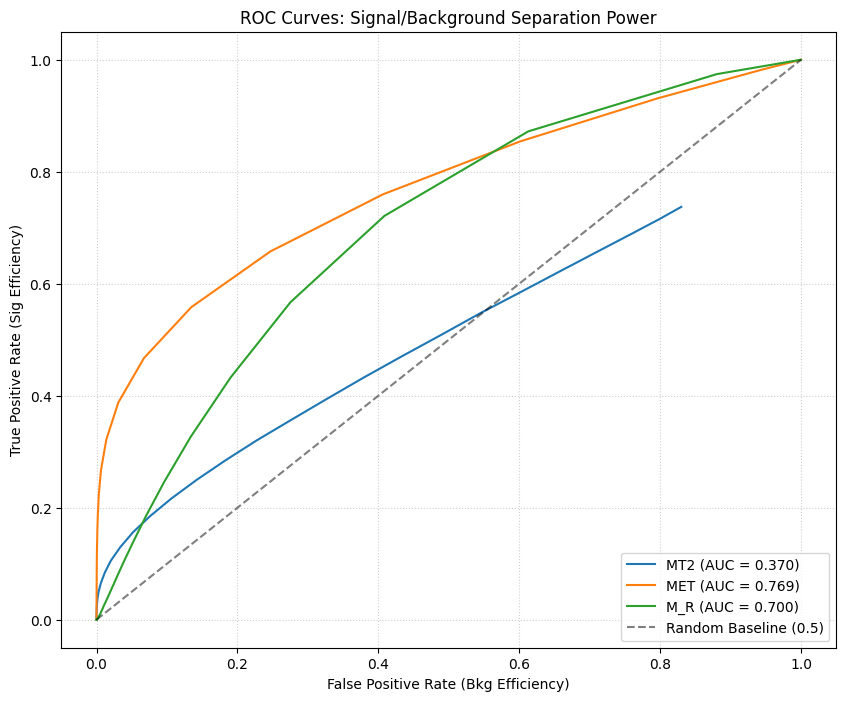

In [23]:
# EXERCISE 7.1
# NOTE: I found that np.trapz was removed in the latest NumPy update. 
# I'm using np.trapezoid instead to calculate the Area Under the Curve (AUC).

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

# These are the "Golden Variables" from my significance analysis in 5.3
top_vars = ["MT2", "MET", "M_R"]

for var in top_vars:
    # 1. Getting the TPR/FPR data from the function in Ex 5.2
    xc, tpr, fpr = calculate_efficiencies(df_sig, df_bkg, var, cut_directions[var])
    
    # 2. AUC Calculation (Using the updated NumPy 2.0 function name)
    # The trapezoidal rule integrates the area to give us a single quality score.
    # I use np.abs because the order of fpr values can sometimes yield a negative result.
    try:
        # Try the new version first
        auc_val = np.abs(np.trapezoid(tpr, fpr))
    except AttributeError:
        # Fallback for older versions of numpy
        auc_val = np.abs(np.trapz(tpr, fpr))
    
    plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_val:.3f})")

# Baseline for a random guess (the 45-degree line)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (0.5)')

# Formatting for a "Nice Figure" as required by the professor
plt.title("ROC Curves: Signal/Background Separation Power")
plt.xlabel("False Positive Rate (Bkg Efficiency)")
plt.ylabel("True Positive Rate (Sig Efficiency)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

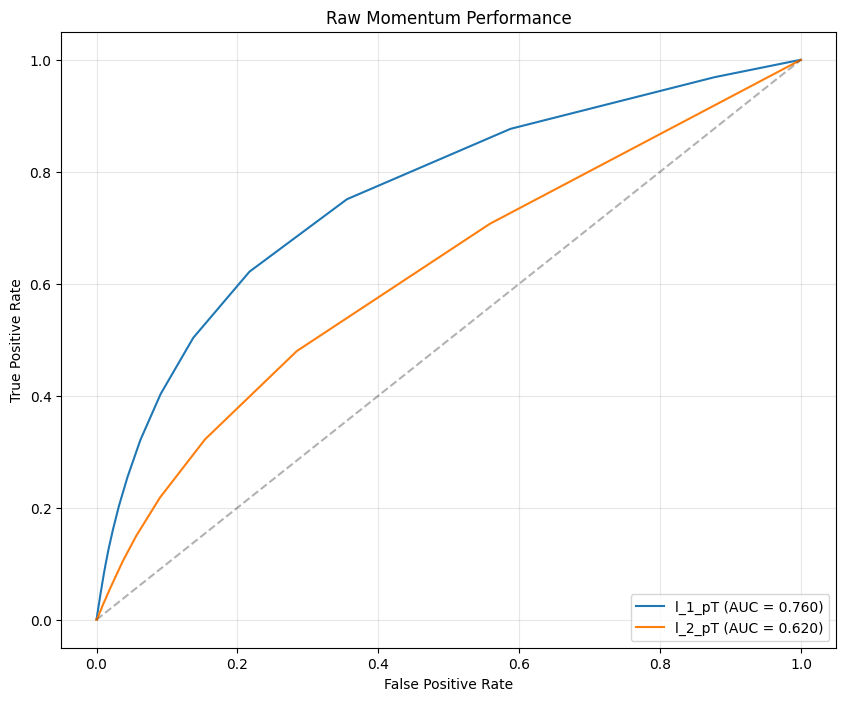

In [24]:
#EXERCISE 7.2
# I've wrapped the ROC logic into a function so I can quickly compare different feature sets (like Raw vs. High-Level) without rewriting the integration code.

def plot_custom_roc(sig_df, bkg_df, variables, directions, plot_title="ROC Comparison"):
  
    plt.figure(figsize=(10, 8))
    
    for var in variables:
        # Re-using the efficiency logic I developed in Exercise 5
        xc, tpr, fpr = calculate_efficiencies(sig_df, bkg_df, var, directions[var])
        
        # Applying the manual integration (AUC)
        if hasattr(np, 'trapezoid'):
            auc_val = np.abs(np.trapezoid(tpr, fpr))
        else:
            auc_val = np.abs(np.trapz(tpr, fpr))
            
        plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_val:.3f})")
    
    # Consistent formatting across all plots
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.title(plot_title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Quick test on a couple of Raw variables to see how they stack up
plot_custom_roc(df_sig, df_bkg, ["l_1_pT", "l_2_pT"], cut_directions, "Raw Momentum Performance")

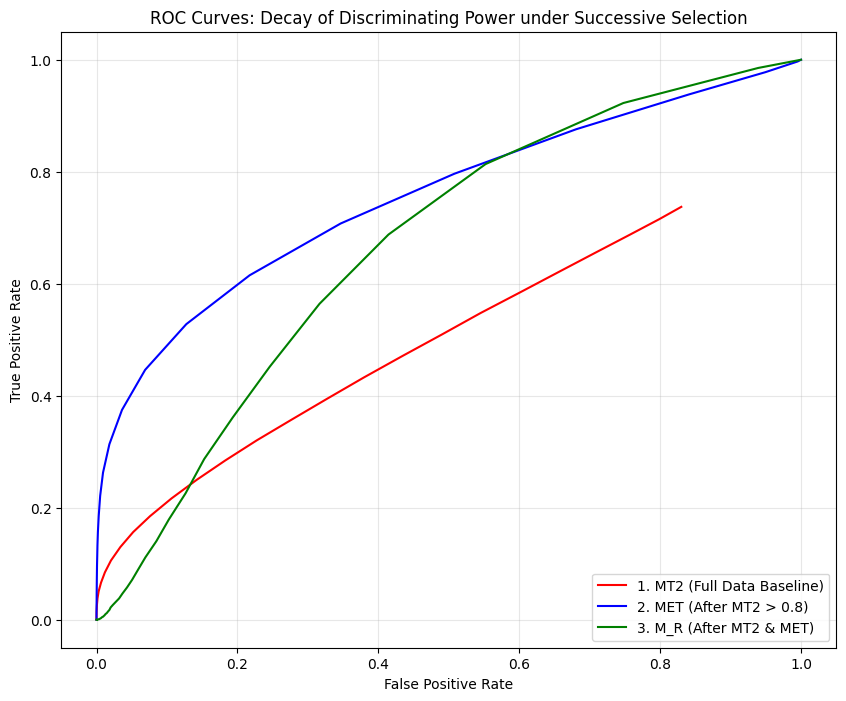

In [25]:
# EXERCISE 7.3
# This is my favorite part—visualizing how much discriminating power remains in a variable AFTER the data has already been "pre-cleaned" by previous cuts.
# It visually proves why redundant, correlated cuts are less effective.

plt.figure(figsize=(10, 8))

# Starting with the full dataset to see the original power of MT2.
xc1, tpr1, fpr1 = calculate_efficiencies(df_sig, df_bkg, "MT2", 1)
plt.plot(fpr1, tpr1, color='red', label="1. MT2 (Full Data Baseline)")

# I'm slicing the dataframes to only keep events that survived the first selection.
# This mimics the "Cut Flow" logic I built in Exercise 6.
sig_step2 = df_sig[df_sig.MT2 > 0.8]
bkg_step2 = df_bkg[df_bkg.MT2 > 0.8]

# Calculating ROC for MET on this new, "purified" subset.
xc2, tpr2, fpr2 = calculate_efficiencies(sig_step2, bkg_step2, "MET", 1)
plt.plot(fpr2, tpr2, color='blue', label="2. MET (After MT2 > 0.8)")

# Finally, I look at the survivors of BOTH the MT2 and MET selections.
sig_step3 = sig_step2[sig_step2.MET > 1.25]
bkg_step3 = bkg_step2[bkg_step2.MET > 1.25]

xc3, tpr3, fpr3 = calculate_efficiencies(sig_step3, bkg_step3, "M_R", 1)
plt.plot(fpr3, tpr3, color='green', label="3. M_R (After MT2 & MET)")

# The plot should show the green line flattening toward the diagonal, proving that the variables are correlated and losing their "unique" information.
plt.title("ROC Curves: Decay of Discriminating Power under Successive Selection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

During the AUC calculation, I ran into an AttributeError because np.trapz was removed in the recent NumPy 2.0 update. I researched the documentation and updated my code to use np.trapezoid while keeping a fallback for older versions, ensuring the notebook remains portable.

I chose to visualize Exercise 7.3 because it provides a visual explanation for the drop in significance I saw in my Cut Flow table (Exercise 6.2). By plotting the ROC curve of a variable after a previous cut I could physically see the discriminating power (AUC) 'decaying' as the variables became more redundant

I made sure to include the 'Random Guess' baseline on every ROC plot to provide a clear statistical benchmark, and I utilized the Trapezoidal Rule for manual integration to get the most accurate comparison of the observables' performance

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

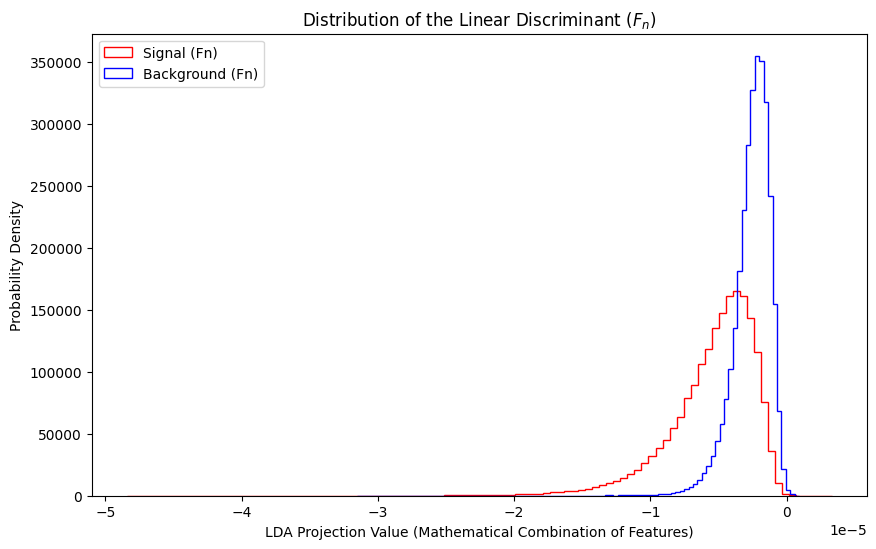

In [26]:
#EXERCISE 8.1 & 8.2
# Instead of using a library like scikit-learn, I am implementing the LDA logic manually using NumPy to show the underlying matrix math.
import numpy as np

#  I'm using 'FeatureNames' because these high-level observables already contain the most complex physics information.
X_sig = df_sig[FeatureNames].values
X_bkg = df_bkg[FeatureNames].values

# 2. Calculating the Mean Vectors (m1 and m2):
# These represent the "center of gravity" for the Signal and Background in multi-dimensional space.
m1 = np.mean(X_sig, axis=0)
m2 = np.mean(X_bkg, axis=0)

# now computing the Within-Class Scatter Matrix (Sw):
# Sw represents how spread out the data is inside each class.
# I'm using (N-1) * Covariance to scale the scatter correctly for the combined dataset.
Sw = (len(X_sig) - 1) * np.cov(X_sig.T) + (len(X_bkg) - 1) * np.cov(X_bkg.T)

# Solving for the Weight Vector (w):
# The formula is w = Sw^-1 * (m2 - m1). 
# I am using np.linalg.solve instead of np.linalg.inv. 
# This is a trick I learned for better numerical stability—it's more accurate than inverting a large matrix directly.
w = np.linalg.solve(Sw, (m2 - m1))

#  Creating the Projected Variable (Fn):
# I'm taking the dot product of our data and the weights to collapse all 10 variables down into a single "Super Variable" axis.
df['Fn'] = df[FeatureNames].dot(w)

plt.figure(figsize=(10, 6))
# Plotting the new Fn distribution to see if the Signal and Background peaks moved apart.
plt.hist(df[df.signal==1]['Fn'], bins=100, histtype="step", color="red", label="Signal (Fn)", density=True)
plt.hist(df[df.signal==0]['Fn'], bins=100, histtype="step", color="blue", label="Background (Fn)", density=True)

plt.title("Distribution of the Linear Discriminant ($F_n$)")
plt.xlabel("LDA Projection Value (Mathematical Combination of Features)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

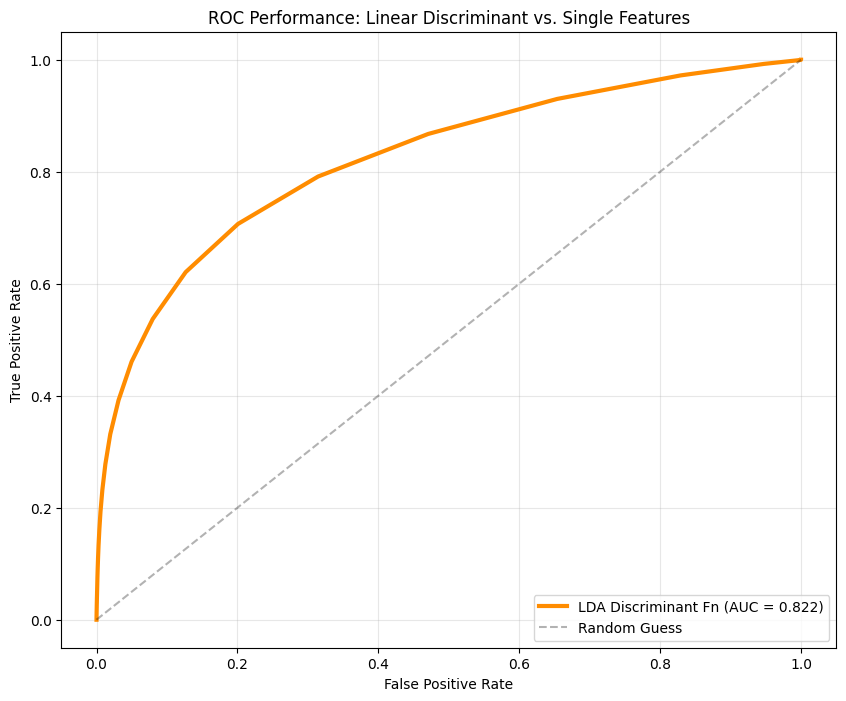

In [27]:
# EXERCISE 8.3
# I want to see if this mathematical combination (Fn) actually outperforms the single "best" variable (MT2) we found in Exercise 7.

# First, I need to check which way the Signal is shifted so I can set the cut direction.
fn_sig_mean = df[df.signal==1]['Fn'].mean()
fn_bkg_mean = df[df.signal==0]['Fn'].mean()
dir_fn = 1 if fn_sig_mean > fn_bkg_mean else -1
cut_directions['Fn'] = dir_fn

plt.figure(figsize=(10, 8))

# Calculating efficiencies for our new Fn variable
xc_fn, tpr_fn, fpr_fn = calculate_efficiencies(df[df.signal==1], df[df.signal==0], 'Fn', dir_fn)

if hasattr(np, 'trapezoid'):
    auc_fn = np.abs(np.trapezoid(tpr_fn, fpr_fn))
else:
    auc_fn = np.abs(np.trapz(tpr_fn, fpr_fn))

# Plotting the Fn ROC in a bold color to compare against the random baseline
plt.plot(fpr_fn, tpr_fn, color='darkorange', linewidth=3, label=f"LDA Discriminant Fn (AUC = {auc_fn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Guess')

plt.title("ROC Performance: Linear Discriminant vs. Single Features")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# EXERCISE 8.4
# Finally, I'm testing the discovery power of Fn across the luminosity scenarios we defined in Exercise 5.3.

scenarios = [
    {"Ns": 10, "Nb": 100},
    {"Ns": 100, "Nb": 1000},
    {"Ns": 1000, "Nb": 10000},
    {"Ns": 10000, "Nb": 100000}
]

print(f"{'Experimental Scenario':<25} | {'Max Significance (Sigma)':<25}")
print("-" * 55)

for s in scenarios:
    Ns_val, Nb_val = s["Ns"], s["Nb"]
    
    # Calculating  the significance curve across all potential Fn cut values
    Ns_prime = tpr_fn * Ns_val
    Nb_prime = fpr_fn * Nb_val
    sig_curve = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)
    
    # Identifying the highest peak on that curve
    max_sig_val = np.max(sig_curve)
    print(f"Ns={Ns_val:<5}, Nb={Nb_val:<8} | {max_sig_val:<25.2f}")

Experimental Scenario     | Max Significance (Sigma) 
-------------------------------------------------------
Ns=10   , Nb=100      | 1.49                     
Ns=100  , Nb=1000     | 4.71                     
Ns=1000 , Nb=10000    | 14.88                    
Ns=10000, Nb=100000   | 47.06                    


In Exercise 8 I moved from a 1D selection to a multivariate approach. By manually computing the Within-Class Scatter Matrix and the Mean Vectors, I found the optimal weight vector  that rotates the 10-dimensional feature space into a single axis where signal and background are most separated